In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [51]:
df = pd.read_csv("car_price.csv")
df.head()

,Unnamed: 0,car_name,car_prices_in_rupee,kms_driven,fuel_type,transmission,ownership,manufacture,engine,Seats
0,0,Jeep Compass 2.0 Longitude Option BSIV,10.03 Lakh,"86,226 kms",Diesel,Manual,1st Owner,2017,1956 cc,5 Seats
1,1,Renault Duster RXZ Turbo CVT,12.83 Lakh,"13,248 kms",Petrol,Automatic,1st Owner,2021,1330 cc,5 Seats
2,2,Toyota Camry 2.5 G,16.40 Lakh,"60,343 kms",Petrol,Automatic,1st Owner,2016,2494 cc,5 Seats
3,3,Honda Jazz VX CVT,7.77 Lakh,"26,696 kms",Petrol,Automatic,1st Owner,2018,1199 cc,5 Seats
4,4,Volkswagen Polo 1.2 MPI Highline,5.15 Lakh,"69,414 kms",Petrol,Manual,1st Owner,2016,1199 cc,5 Seats


# Data Cleaning

In [52]:
df['car_prices_in_rupee'] = (df['car_prices_in_rupee'].str.replace('Crore', 'e7').str.replace('Lakh', 'e5').str.replace(' ', '').str.replace(',', '').astype(float))  #converting lakh, crore in numbers & remove space and coma
df['kms_driven'] = df['kms_driven'].str.replace('kms', '',).str.replace(',', '',).str.strip()  #remove kms & coma
df['Seats'] = df['Seats'].str.replace('Seats', '',).str.replace(',', '',).str.strip()
df.rename(columns={'engine' : 'engine(cc)'}, inplace=True)
df['engine(cc)'] = df['engine(cc)'].str.replace('cc', '',).str.strip()
df['ownership'] = df['ownership'].str.replace( r'[^0-9]', '', regex=True)  #remove all str except 0-9
df.head()

,Unnamed: 0,car_name,car_prices_in_rupee,kms_driven,fuel_type,transmission,ownership,manufacture,engine(cc),Seats
0,0,Jeep Compass 2.0 Longitude Option BSIV,1003000.0,86226,Diesel,Manual,1,2017,1956,5
1,1,Renault Duster RXZ Turbo CVT,1283000.0,13248,Petrol,Automatic,1,2021,1330,5
2,2,Toyota Camry 2.5 G,1640000.0,60343,Petrol,Automatic,1,2016,2494,5
3,3,Honda Jazz VX CVT,777000.0,26696,Petrol,Automatic,1,2018,1199,5
4,4,Volkswagen Polo 1.2 MPI Highline,515000.0,69414,Petrol,Manual,1,2016,1199,5


In [53]:
#Independent & Dependent Features
from sklearn.model_selection import train_test_split
x= df.drop(['car_prices_in_rupee'], axis=1)   #all features except 'car_prices_in_rupee'
y= df['car_prices_in_rupee']

x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2)
print(x_train.shape)
print(x_test.shape)

(4409, 9)
(1103, 9)


# Text to Numeric

In [54]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder ,StandardScaler
import category_encoders as ce       #for Target_encoder
from sklearn.compose import ColumnTransformer

Target_encoder= ce.TargetEncoder(smoothing=10)   #smoothing saves from overfitting

#transformer used to convert i/p to numeric in min line of code
transformer= ColumnTransformer( transformers=[
    
    ('t1',OneHotEncoder(drop='first', handle_unknown='ignore'),['fuel_type', 'transmission']),  #'name',method,columns
    ('t2',OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ['ownership', 'manufacture']),
    ('t3',StandardScaler(),['kms_driven', 'engine(cc)','Seats']),
    ('t4',Target_encoder, ['car_name'])
                            ],remainder='passthrough')  

x_train_transformed = transformer.fit_transform(x_train, y_train)  #Targert Encoder need both x&y to fill name with avg price
x_test_transformed = transformer.transform(x_test)

x_train_transformed

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -3.41955766e-01,  4.72050143e+05,  2.12400000e+03],
       [ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -3.41955766e-01,  1.21731901e+06,  4.71600000e+03],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -3.41955766e-01,  1.09510607e+06,  5.11000000e+02],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -3.41955766e-01,  1.09134052e+06,  1.70600000e+03],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -3.41955766e-01,  1.02628229e+06,  7.48000000e+02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -3.41955766e-01,  5.93491995e+05,  3.42000000e+03]],
      shape=(4409, 12))

# Model Training & Model Selection

In [55]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [56]:
#Creating a fx to Evaluate model
def evaluate_model(true, predicted):
    mae= mean_absolute_error(true, predicted)
    mse= mean_squared_error(true, predicted)
    rmse= np.sqrt(mean_squared_error(true, predicted))
    R2_score= r2_score(true, predicted)

    return mae, mse, rmse, R2_score

In [57]:
#Model Training
models= {
    "Linear Regression" : LinearRegression(),
    "Lasso" : Lasso(),
    "Ridge" : Ridge(),
    "K-Neighbors Regressor" : KNeighborsRegressor(),
    "Decision Tree" : DecisionTreeRegressor(ccp_alpha=0.01),
    "Random Forest Regressor" : RandomForestRegressor()
}

r2_score_list= []   #R2score of all models, used for visualization

for i in range(len(list(models))):
    model= list(models.values())[i] 
    model.fit(x_train_transformed, y_train)  #Train Model

    #Make Prediction
    y_train_pred= model.predict(x_train_transformed)
    y_test_pred= model.predict(x_test_transformed)

    #Evaluate Train and Test Dataset
    model_train_mae, model_train_mse, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_mse, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)
    
    print("****** '", list(models.keys())[i], "' ******", '\n')

    print('Model performance for Training set:')
    print("RMSE: {:.4f}".format(model_train_rmse))  #using .format for o/p (:.4f) like 0.4443 till 4 decimals
    print("MAE: {:.4f}".format(model_train_mae))
    print("MSE: {:.4f}".format(model_train_mse))
    print("R2 Score: {:.4f}".format(model_train_r2 *100))

    print('-----------------------------------')

    print('Model performance for Test set:')
    print("RMSE: {:.4f}".format(model_test_rmse))
    print("MAE: {:.4f}".format(model_test_mae))
    print("MSE: {:.4f}".format(model_test_mse))
    print("R2 Score: {:.4f}".format(model_test_r2 *100))
    r2_score_list.append(model_test_r2 *100)


    print('='*50)
    print('='*50, '\n')

****** ' Linear Regression ' ****** 

Model performance for Training set:
RMSE: 741722.7973
MAE: 460434.9965
MSE: 550152708053.7390
R2 Score: 85.9568
-----------------------------------
Model performance for Test set:
RMSE: 974607.4206
MAE: 585165.2024
MSE: 949859624225.2048
R2 Score: 74.5183

****** ' Lasso ' ****** 

Model performance for Training set:
RMSE: 741722.7979
MAE: 460434.6052
MSE: 550152708905.2529
R2 Score: 85.9568
-----------------------------------
Model performance for Test set:
RMSE: 974607.9981
MAE: 585165.2237
MSE: 949860749942.3258
R2 Score: 74.5183

****** ' Ridge ' ****** 

Model performance for Training set:
RMSE: 741724.5654
MAE: 460412.1340
MSE: 550155330930.4369
R2 Score: 85.9567
-----------------------------------
Model performance for Test set:
RMSE: 974624.0982
MAE: 585152.6919
MSE: 949892132696.0649
R2 Score: 74.5174

****** ' K-Neighbors Regressor ' ****** 

Model performance for Training set:
RMSE: 304345.4648
MAE: 138388.9144
MSE: 92626161927.5541
R2 S

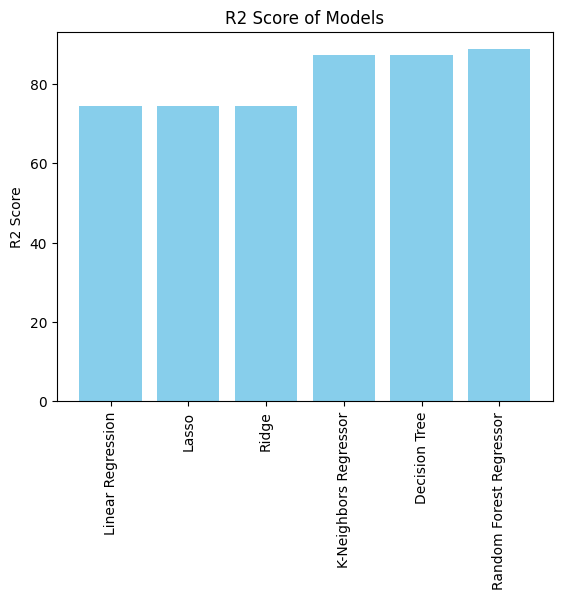

In [58]:
#Bar Graph to showing R2 Score of Models

model_names= list(models.keys())

plt.bar(model_names, r2_score_list, color='skyblue')
plt.xticks(rotation=90)
plt.ylabel("R2 Score")
plt.title("R2 Score of Models")
plt.show()

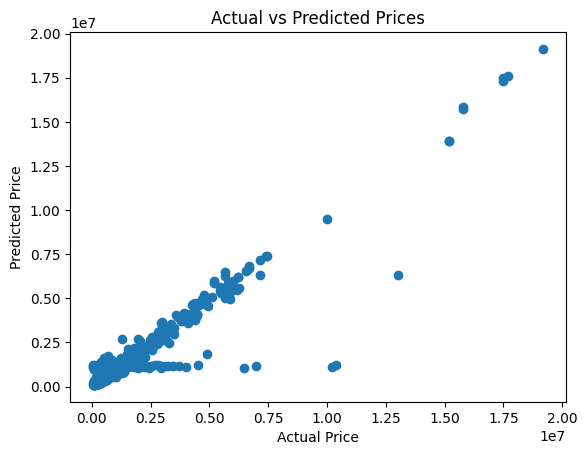

In [59]:
# Relation btw Actual vs Predicted Prices
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

# Hyperparameter tuning

In [60]:
#Initialize few parameters for Hyperparameter tuning of Best Performing Models

rf_params= { 'max_depth' : [5,10,15,18,None,30,35,40],
             'n_estimators' : [100,200,300,500,900],
             'min_samples_split' : [2,6,8,10,12,15],
             'max_features' : [4,6,5,7,'auto',10]
           }

dt_params= {'criterion' : ['squared_error','friedman_mse','absolute_error','poisson'],
            'splitter' : ['best','random'],
            'max_depth' : [5,10,15,20,'None'],
            'min_samples_split' : [2,5,10,15],
            'min_samples_leaf' : [1,2,5,10],
            'ccp_alpha' : [0.0, 0.01, 0.001, 0.1]
            }

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

#Finding Best Parameters for Random Forest
random= RandomizedSearchCV(
    estimator= RandomForestRegressor(),
    param_distributions= rf_params,
    n_iter= 100,
    cv= 3,
    verbose= 2,
    n_jobs= -1
)

random.fit(x_train_transformed, y_train)

Fitting 3 folds for each of 100 candidates, totalling 300 fits


[CV] END max_depth=15, max_features=auto, min_samples_split=10, n_estimators=300; total time=   0.0s
[CV] END max_depth=15, max_features=auto, min_samples_split=10, n_estimators=300; total time=   0.0s
[CV] END max_depth=15, max_features=auto, min_samples_split=10, n_estimators=300; total time=   0.0s
[CV] END max_depth=None, max_features=4, min_samples_split=8, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=4, min_samples_split=8, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=4, min_samples_split=8, n_estimators=100; total time=   0.3s
[CV] END max_depth=15, max_features=auto, min_samples_split=2, n_estimators=300; total time=   0.0s
[CV] END max_depth=15, max_features=auto, min_samples_split=2, n_estimators=300; total time=   0.0s
[CV] END max_depth=15, max_features=auto, min_samples_split=2, n_estimators=300; total time=   0.0s
[CV] END max_depth=30, max_features=5, min_samples_split=6, n_estimators=100; total time=   0.3s
[CV

In [ ]:
print(random.best_params_)

{'n_estimators': 900, 'min_samples_split': 2, 'max_features': 10, 'max_depth': 40}


In [ ]:
#Finding Best Parameters for Decision Tree
random= RandomizedSearchCV(
    estimator= DecisionTreeRegressor(),
    param_distributions= dt_params,
    n_iter= 100,
    cv= 3,
    verbose= 2,
    n_jobs= -1
)

random.fit(x_train_transformed, y_train)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
[CV] END ccp_alpha=0.01, criterion=squared_error, max_depth=10, min_samples_leaf=2, min_samples_split=2, splitter=random; total time=   0.0s
[CV] END ccp_alpha=0.01, criterion=squared_error, max_depth=10, min_samples_leaf=2, min_samples_split=2, splitter=random; total time=   0.0s
[CV] END ccp_alpha=0.01, criterion=squared_error, max_depth=10, min_samples_leaf=2, min_samples_split=2, splitter=random; total time=   0.0s
[CV] END ccp_alpha=0.1, criterion=absolute_error, max_depth=None, min_samples_leaf=1, min_samples_split=10, splitter=random; total time=   0.0s
[CV] END ccp_alpha=0.1, criterion=absolute_error, max_depth=None, min_samples_leaf=1, min_samples_split=10, splitter=random; total time=   0.0s
[CV] END ccp_alpha=0.1, criterion=absolute_error, max_depth=None, min_samples_leaf=1, min_samples_split=10, splitter=random; total time=   0.0s
[CV] END ccp_alpha=0.001, criterion=absolute_error, max_depth=None, min_samples_le

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
78 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
78 fits failed with the following error:
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeRegressor()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'ccp_alpha': [0.0, 0.01, ...], 'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be use

In [ ]:
print(random.best_params_)

{'splitter': 'best', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 15, 'criterion': 'squared_error', 'ccp_alpha': 0.0}


In [ ]:
#Model Training with best param of Random forest
models= {
    "Random Forest Regressor" : RandomForestRegressor(n_estimators=100, min_samples_split= 2, max_features= 10, max_depth= None),
    "Decision Tree" : DecisionTreeRegressor(splitter='best', min_samples_split=10, min_samples_leaf= 1, max_depth=15, criterion='squared_error', ccp_alpha=0.0)
}

for i in range(len(list(models))):
    model= list(models.values())[i] 
    model.fit(x_train_transformed, y_train)  #Train Model

    #Make Prediction
    y_train_pred= model.predict(x_train_transformed)
    y_test_pred= model.predict(x_test_transformed)

    #Evaluate Train and Test Dataset
    model_train_mae, model_train_mse, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_mse, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)
    
    print("****** '", list(models.keys())[i], "' ******", '\n')

    print('Model performance for Training set:')
    print("RMSE: {:.4f}".format(model_train_rmse))  #using .format for o/p (:.4f) like 0.4443 till 4 decimals
    print("MAE: {:.4f}".format(model_train_mae))
    print("MSE: {:.4f}".format(model_train_mse))
    print("R2 Score: {:.4f}".format(model_train_r2 *100))

    print('-----------------------------------')

    print('Model performance for Test set:')
    print("RMSE: {:.4f}".format(model_test_rmse))
    print("MAE: {:.4f}".format(model_test_mae))
    print("MSE: {:.4f}".format(model_test_mse))
    print("R2 Score: {:.4f}".format(model_test_r2 *100))

    print('='*50)
    print('='*50, '\n')

****** ' Random Forest Regressor ' ****** 

Model performance for Training set:
RMSE: 114146.7862
MAE: 44986.9128
MSE: 13029488792.4244
R2 Score: 99.6664
-----------------------------------
Model performance for Test set:
RMSE: 639505.3162
MAE: 266397.2222
MSE: 408967049430.6918
R2 Score: 89.1741

****** ' Decision Tree ' ****** 

Model performance for Training set:
RMSE: 151135.0215
MAE: 66179.7207
MSE: 22841794736.6032
R2 Score: 99.4151
-----------------------------------
Model performance for Test set:
RMSE: 671058.8426
MAE: 284718.1805
MSE: 450319970247.5848
R2 Score: 88.0794



# Applying PCA

In [ ]:
#Use to reduce features for fast processing
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

In [ ]:
pca= PCA(n_components=0.95)
x_train_pca= pca.fit_transform(x_train_transformed)
x_test_pca= pca.transform(x_test_transformed)

print('Original Train features:',x_train_transformed.shape[1])
print('Reduced Train features after PCA:',x_train_pca.shape[1])

print('Original Test features:',x_test_transformed.shape[1])
print('Reduced Test features after PCA:',x_test_pca.shape[1])

Original Train features: 11
Reduced Train features after PCA: 1
Original Test features: 11
Reduced Test features after PCA: 1


In [ ]:
models= {
    "Random Forest Regressor" : RandomForestRegressor(n_estimators=100, min_samples_split= 2, max_features= 10, max_depth= None)
}

for i in range(len(list(models))):
    model= list(models.values())[i] 
    model.fit(x_train_pca, y_train)  #Train Model

    #Make Prediction
    y_train_pred= model.predict(x_train_pca)
    y_test_pred= model.predict(x_test_pca)

    #Evaluate Train and Test Dataset
    model_train_mae, model_train_mse, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_mse, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)
    
    print("****** '", list(models.keys())[i], "' ******", '\n')

    print('Model performance for Training set:')
    print("RMSE: {:.4f}".format(model_train_rmse))  #using .format for o/p (:.4f) like 0.4443 till 4 decimals
    print("MAE: {:.4f}".format(model_train_mae))
    print("MSE: {:.4f}".format(model_train_mse))
    print("R2 Score: {:.4f}".format(model_train_r2 *100))

    print('-----------------------------------')

    print('Model performance for Test set:')
    print("RMSE: {:.4f}".format(model_test_rmse))
    print("MAE: {:.4f}".format(model_test_mae))
    print("MSE: {:.4f}".format(model_test_mse))
    print("R2 Score: {:.4f}".format(model_test_r2 *100))

    print('='*50)
    print('='*50, '\n')

****** ' Random Forest Regressor ' ****** 

Model performance for Training set:
RMSE: 177106.5907
MAE: 57999.3740
MSE: 31366744461.7688
R2 Score: 99.1968
-----------------------------------
Model performance for Test set:
RMSE: 712561.8223
MAE: 294650.2938
MSE: 507744350590.8801
R2 Score: 86.5593

